In [1]:
# =================================================================
# 03b_chronicle_rain_analysis_and_standardization
# Actions: 
# 1. Standardize area (Mollweide) and recalculate PFDI for consistency.
# 2. Perform Spatial-Temporal Rainfall Intensity Analysis (30m - 24h).
# =================================================================

import pandas as pd
import numpy as np
import os
from tqdm import tqdm
import gc

# --- 1. CONFIGURATION ---
# Using the exact path you confirmed
RAIN_INPUT_PATH = r"\\vscifs\hydrolab1\hydrolab\home\Raz\Research\chronicle\chronicle_urban_df_with_IMERG_FULL.pkl"
RAIN_MASTER_FILE_PATH = r"\\vscifs\hydrolab1\hydrolab\home\Raz\Research\chronicle\chronicle_rain_master_V07.pkl"

DURATIONS = [30, 60, 120, 240, 360, 720, 1440] # minutes

# --- 2. LOAD DATA ---
print(f"Loading chronicle V07 rainfall data: {RAIN_INPUT_PATH}")
chronicle_events = pd.read_pickle(RAIN_INPUT_PATH)

# --- 3. CLEAN SLATE STEP ---
# Removing any existing intensity columns to ensure V07 data is fresh and unpolluted
cols_to_remove = [f'peak_intensity_{d}m' for d in DURATIONS] + ['max_intensity_30m', 'total_precipitation_mm']
chronicle_events = chronicle_events.drop(columns=[c for c in cols_to_remove if c in chronicle_events.columns])

print(f"Clean Slate complete. Processing {len(chronicle_events)} events from V07.")

# --- 4. PREPARE FOR ANALYSIS ---
# Ensure imerg_matrix is valid and not null
df_analysis = chronicle_events[chronicle_events['imerg_matrix'].notnull()].copy()
print(f"Events with valid IMERG matrices: {len(df_analysis)}")

Loading chronicle V07 rainfall data: \\vscifs\hydrolab1\hydrolab\home\Raz\Research\chronicle\chronicle_urban_df_with_IMERG_FULL.pkl
Clean Slate complete. Processing 844982 events from V07.
Events with valid IMERG matrices: 844982


In [2]:
chronicle_events.columns

Index(['Unnamed: 0', 'uuid', 'area_km2', 'version', 'start_time', 'end_time',
       'duration_days', 'geometry_wkt', 'urban_built_up_area_m2',
       'polygon_total_area_m2', 'urban_percentage', 'event_id',
       'poly_area_km2', 'upa_max', 'upa_p95', 'upa_p99', 'PFDI_p95',
       'PFDI_p99', 'PFDI_max', 'imerg_matrix', 'imerg_mask', 'imerg_meta',
       'imerg_type'],
      dtype='object')

In [3]:
# =================================================================
# STEP 0: CLEAN SLATE (PREVENT COLUMN POLLUTION)
# =================================================================
# Removing any old intensity columns to ensure we don't carry over logic errors
old_intensity_cols = [c for c in chronicle_events.columns if 'max_rainfall_intens' in c]
if old_intensity_cols:
    print(f"Removing {len(old_intensity_cols)} existing intensity columns for a clean run...")
    chronicle_events = chronicle_events.drop(columns=old_intensity_cols)

# =================================================================
# ACTION 1: AREA STANDARDIZATION & MULTI-PFDI SYNC
# =================================================================
print("Step 1: Standardizing area and syncing PFDI metrics (p95, p99, max)...")

# Update master area to km2 using the precision Mollweide area
chronicle_events['area_km2'] = chronicle_events['polygon_total_area_m2'] / 1e6

# Synchronizing all PFDI metrics with the new standardized area
metrics_to_sync = [
    ('upa_p95', 'PFDI_p95'),
    ('upa_p99', 'PFDI_p99'),
    ('upa_max', 'PFDI_max')
]

for upa_col, pfdi_col in metrics_to_sync:
    if upa_col in chronicle_events.columns:
        chronicle_events[pfdi_col] = np.where(
            chronicle_events['area_km2'] > 0,
            chronicle_events[upa_col] / chronicle_events['area_km2'],
            0
        )

# Remove redundant columns to keep the dataset lean
redundant_cols = ['polygon_total_area_m2', 'poly_area_km2', 'Unnamed: 0', 'version']
chronicle_events = chronicle_events.drop(columns=[c for c in redundant_cols if c in chronicle_events.columns])

# =================================================================
# ACTION 2: INTENSITY ANALYSIS (Spatial then Temporal)
# =================================================================
print(f"Step 2: Calculating Peak Intensities for {len(chronicle_events)} events...")

event_intensity_list = []

for idx, row in tqdm(chronicle_events.iterrows(), total=len(chronicle_events)):
    rain_matrix = row['imerg_matrix']
    polygon_mask = row['imerg_mask']
    
    if not isinstance(rain_matrix, np.ndarray) or rain_matrix.size == 0 or polygon_mask.sum() == 0:
        continue

    # Spatial average across the entire polygon mask
    spatial_mean_series = np.nanmean(rain_matrix[:, polygon_mask == 1], axis=1)
    hyetograph = pd.Series(spatial_mean_series)

    peak_stats = {'event_id': row['event_id']}
    
    # Temporal rolling max for each duration
    for duration_min in DURATIONS:
        window_steps = int(duration_min / 30)
        if len(hyetograph) >= window_steps:
            peak_val = hyetograph.rolling(window=window_steps).mean().max()
            peak_stats[f"{duration_min}_max_rainfall_intens"] = peak_val
        else:
            peak_stats[f"{duration_min}_max_rainfall_intens"] = np.nan
            
    event_intensity_list.append(peak_stats)

# =================================================================
# FINAL MERGE & SAVE
# =================================================================
intensity_summary = pd.DataFrame(event_intensity_list)
final_master_dataset = chronicle_events.merge(intensity_summary, on='event_id', how='left')

print(f"\nProcessing Complete. Total events: {len(final_master_dataset)}")
final_master_dataset.to_pickle(RAIN_MASTER_FILE_PATH)
print(f"SUCCESS! Clean master dataset saved to: {RAIN_MASTER_FILE_PATH}")

Step 1: Standardizing area and syncing PFDI metrics (p95, p99, max)...
Step 2: Calculating Peak Intensities for 844982 events...


100%|████████████████████████████████████████████████████████████████████████| 844982/844982 [07:58<00:00, 1764.50it/s]



Processing Complete. Total events: 844982
SUCCESS! Clean master dataset saved to: \\vscifs\hydrolab1\hydrolab\home\Raz\Research\chronicle\chronicle_rain_master_V07.pkl


In [4]:
final_master_dataset

,uuid,area_km2,start_time,end_time,duration_days,geometry_wkt,urban_built_up_area_m2,urban_percentage,event_id,upa_max,...,imerg_mask,imerg_meta,imerg_type,30_max_rainfall_intens,60_max_rainfall_intens,120_max_rainfall_intens,240_max_rainfall_intens,360_max_rainfall_intens,720_max_rainfall_intens,1440_max_rainfall_intens
0,1422c1c0986549d7a3c7d10a09208098,17.902320,9.598176e+08,9.598176e+08,1,"POLYGON ((-98.923354 19.259108, -98.916374 19....",6055133.0,33.823174,296,7775.601562,...,"[[1, 0]]","{'origin_top_left': (19.288329, -98.923354), '...",final,3.940000,3.605000,3.602500,2.598750,1.812500,0.923750,0.793125
1,43553235080041299c3e48978885c635,29.849550,9.598176e+08,9.598176e+08,1,"POLYGON ((-98.953929 19.329468, -98.883774 19....",8815066.0,29.531655,297,7266.895020,...,"[[1, 0], [0, 0]]","{'origin_top_left': (19.346044, -98.953929), '...",final,6.520000,6.495000,6.145000,4.931250,3.557500,1.952917,1.090417
2,6532dc29aaa645239f52ad164489e0aa,1760.002208,9.598176e+08,9.598176e+08,1,"POLYGON ((95.067367 28.023449, 95.288819 28.09...",6223800.0,0.353625,298,255259.687500,...,"[[0, 1, 1, 1, 1, 0], [0, 1, 1, 1, 1, 0], [1, 1...","{'origin_top_left': (28.320151, 95.067367), 's...",final,5.135833,3.400000,3.329792,2.017083,1.375069,1.137462,0.638125
3,bd7267cb286448798c31cfab0f6a0f95,11.800292,9.598176e+08,9.598176e+08,1,"POLYGON ((-98.97432499999999 19.337026, -98.93...",3757833.0,31.845253,299,8171.314453,...,"[[1], [0]]","{'origin_top_left': (19.337026, -98.974325), '...",final,6.520000,6.495000,6.145000,4.931250,3.557500,1.952917,1.090417
4,d2205ca5dd1c42f2b6ca67ab9bf1e9e8,105.652324,9.598176e+08,9.598176e+08,1,"POLYGON ((1.3503293 43.604335, 1.4399303 43.66...",28337179.0,26.821160,300,10537.763672,...,"[[1, 1, 0], [1, 1, 0]]","{'origin_top_left': (43.668714, 1.3503293), 's...",final,5.850000,5.451250,3.862500,1.931250,1.287500,0.643750,0.325469
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
844977,7b744b78809940dda54c46c908bad7b1,117.723980,1.760141e+09,1.760314e+09,3,"POLYGON ((121.47561 23.628529, 121.3576 23.605...",1213301.0,1.030632,879486,296.186829,...,"[[1, 1, 0], [1, 0, 0]]","{'origin_top_left': (23.710642, 121.3576), 'sc...",final,0.036667,0.018333,0.009167,0.004583,0.003056,0.001528,0.000764
844978,7abe415d03384c0eadb627ad12e2f453,0.256982,1.760141e+09,1.760227e+09,2,"POLYGON ((-98.05881100000001 20.184761, -98.05...",41216.0,16.038485,879487,0.281138,...,[[1]],"{'origin_top_left': (20.188555, -98.058811), '...",final,26.650000,21.115000,17.297500,11.882500,9.420833,5.503750,5.313333
844979,7c06968af134455b8e2de165b43d4e30,0.515520,1.760141e+09,1.760227e+09,2,"POLYGON ((-98.76087200000001 20.051374, -98.75...",249611.0,48.419233,879488,133.479874,...,[[1]],"{'origin_top_left': (20.05725, -98.760872), 's...",final,18.410000,12.440000,11.270000,8.870000,7.479167,4.424167,3.632917
844980,7c72b95b2aeb477591c1ab72b147baf3,1.081058,1.760141e+09,1.760141e+09,1,"POLYGON ((-94.456058 18.147165, -94.449169 18....",384721.0,35.587455,879489,0.617925,...,[[1]],"{'origin_top_left': (18.154412, -94.456058), '...",final,19.779999,18.924999,17.742500,12.473750,10.525000,6.798750,3.971667


Generating histograms for rainfall intensities...


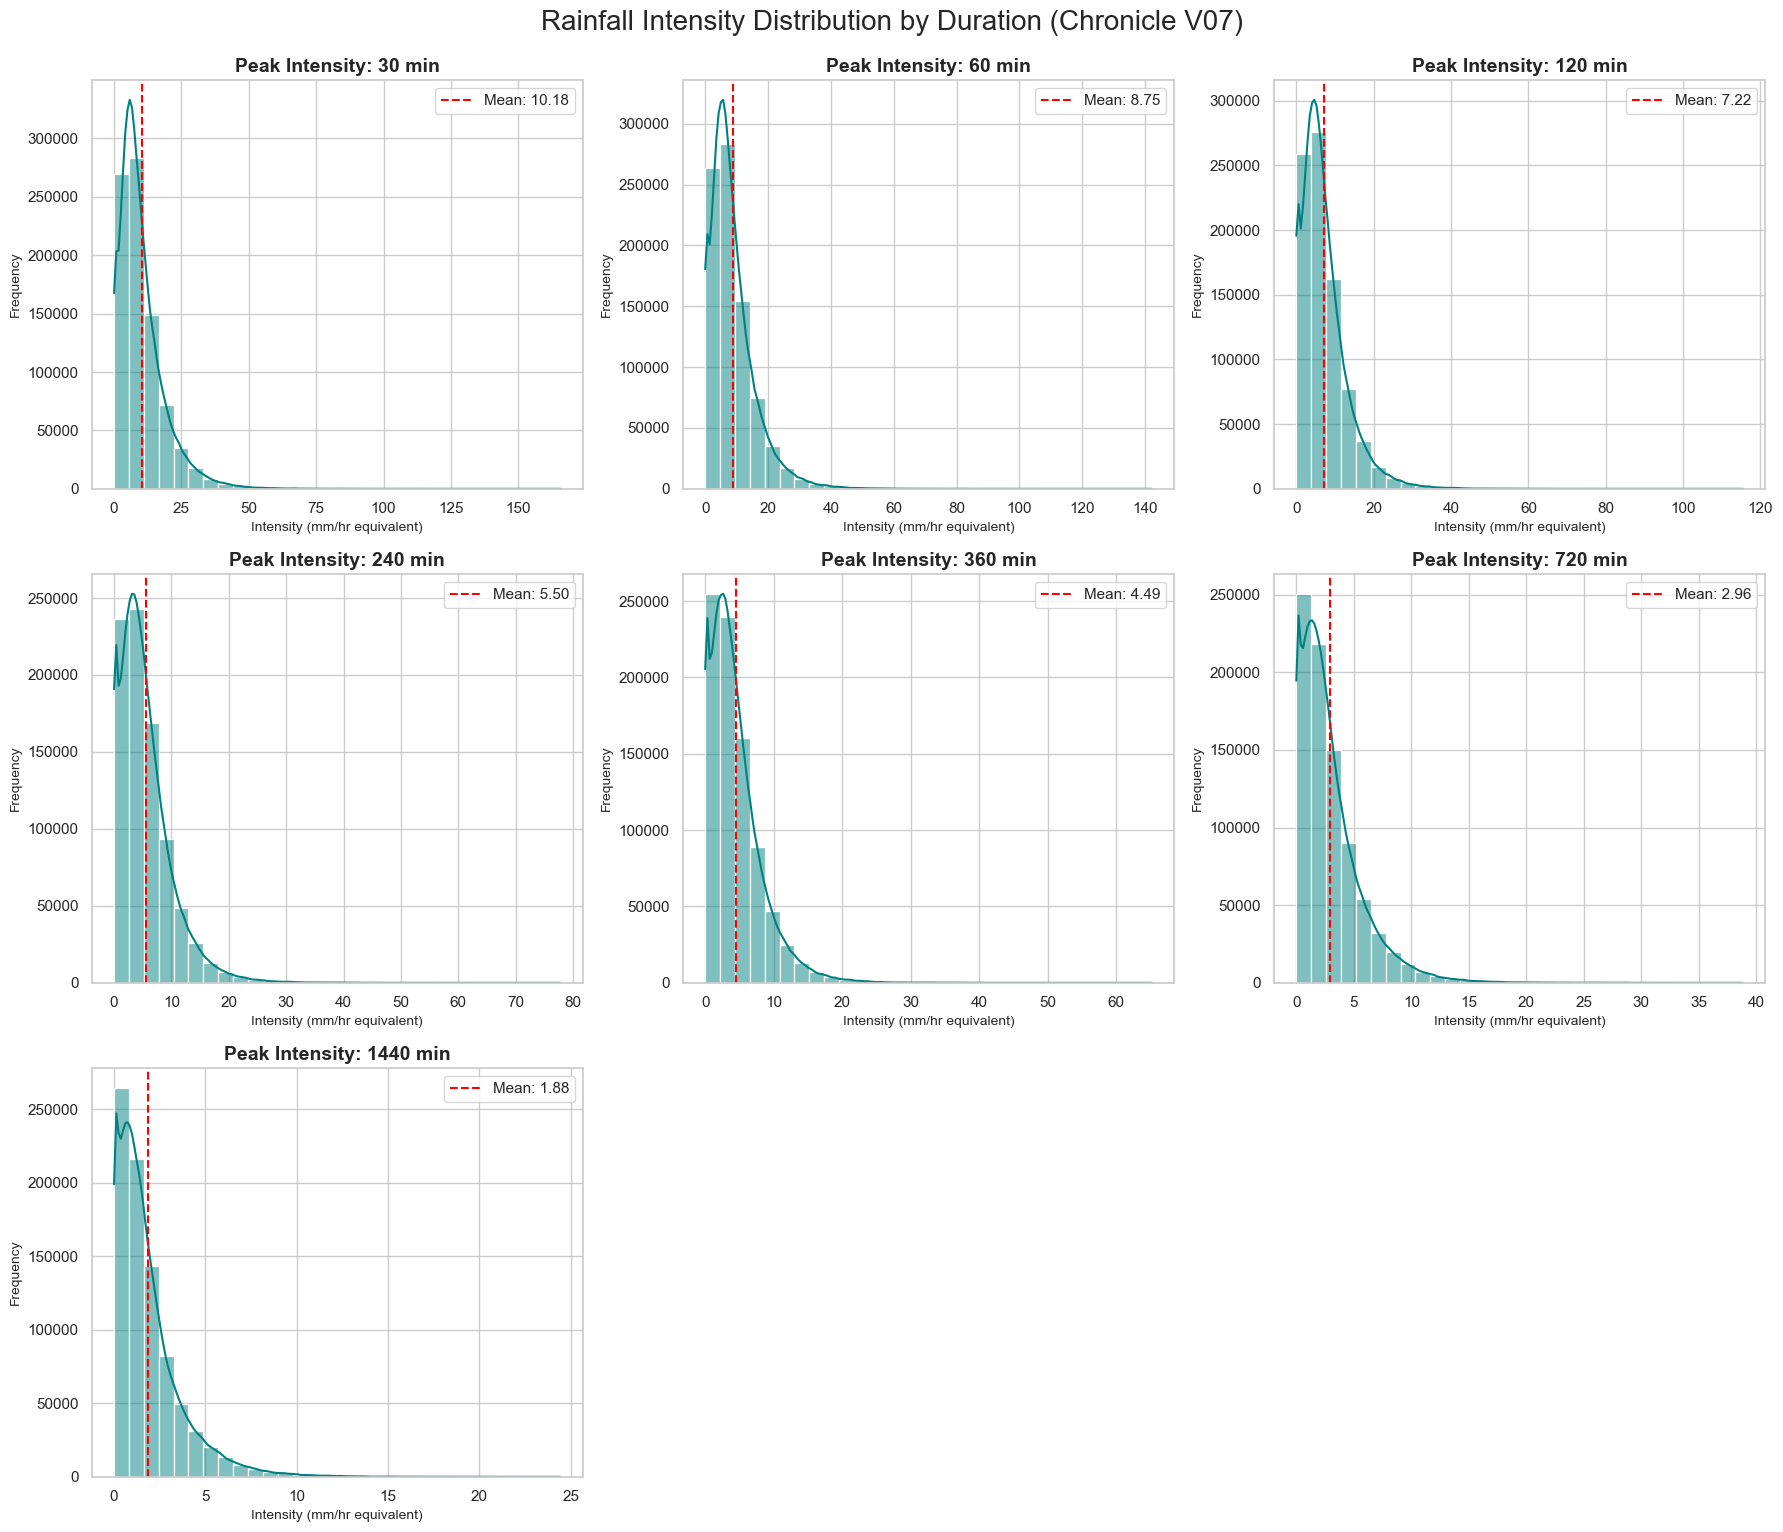


Quick Summary Statistics for Intensities:
       30_max_rainfall_intens  60_max_rainfall_intens  \
count              844377.000              844377.000   
mean                   10.180                   8.748   
std                     8.458                   7.135   
min                     0.000                   0.000   
25%                     4.535                   3.939   
50%                     8.142                   7.135   
75%                    13.545                  11.694   
max                   165.700                 142.125   

       120_max_rainfall_intens  240_max_rainfall_intens  \
count               844377.000               844377.000   
mean                     7.218                    5.504   
std                      5.855                    4.559   
min                      0.000                    0.000   
25%                      3.220                    2.325   
50%                      5.965                    4.530   
75%                      9.730

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. SET VISUAL STYLE ---
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (16, 12)

# Identify the columns we just created
intensity_cols = [f"{d}_max_rainfall_intens" for d in DURATIONS]

# --- 2. CREATE PLOTS ---
# Create a grid of subplots (e.g., 3 rows x 3 columns)
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(18, 15))
axes = axes.flatten()

print("Generating histograms for rainfall intensities...")

for i, duration in enumerate(DURATIONS):
    col_name = f"{duration}_max_rainfall_intens"
    ax = axes[i]
    
    if col_name in final_master_dataset.columns:
        # Filter out NaNs for plotting
        data_to_plot = final_master_dataset[col_name].dropna()
        
        # Plot histogram with KDE
        sns.histplot(data_to_plot, bins=30, kde=True, ax=ax, color='teal')
        
        # Formatting
        ax.set_title(f'Peak Intensity: {duration} min', fontsize=14, fontweight='bold')
        ax.set_xlabel('Intensity (mm/hr equivalent)', fontsize=10)
        ax.set_ylabel('Frequency', fontsize=10)
        
        # Add some basic stats to the plot
        mean_val = data_to_plot.mean()
        max_val = data_to_plot.max()
        ax.axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.2f}')
        ax.legend()

# Remove empty subplots (if any)
for j in range(len(DURATIONS), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.suptitle("Rainfall Intensity Distribution by Duration (Chronicle V07)", fontsize=20, y=1.02)
plt.show()

# --- 3. SUMMARY STATISTICS ---
print("\nQuick Summary Statistics for Intensities:")
print(final_master_dataset[intensity_cols].describe().round(3))

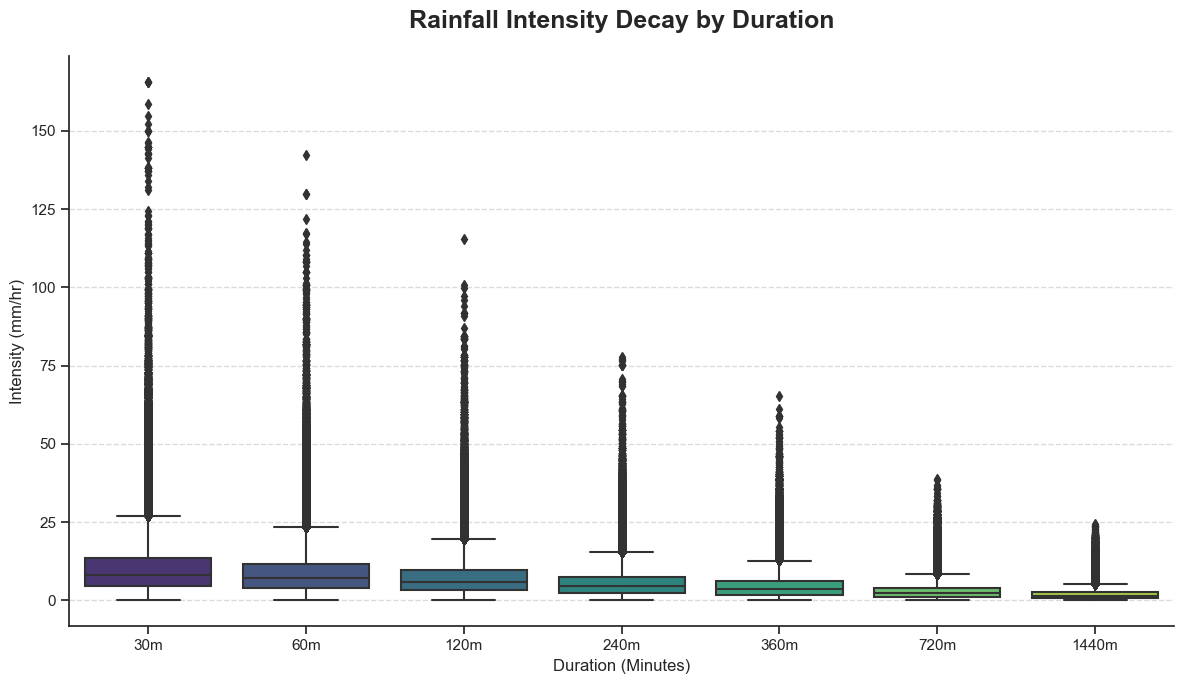


Intensity Percentiles by Duration (mm/hr):
        30m    60m   120m   240m   360m   720m  1440m
0.25   4.53   3.94   3.22   2.32   1.80   1.08   0.63
0.50   8.14   7.13   5.96   4.53   3.64   2.28   1.38
0.75  13.55  11.69   9.73   7.51   6.16   4.05   2.52
0.90  20.72  17.63  14.49  11.22   9.31   6.40   4.17
0.99  39.80  33.47  27.34  21.04  17.55  12.34   8.53


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. DATA PREPARATION (Melting for Seaborn) ---
# We melt the dataframe to a "long" format which is ideal for categorical plotting
intensity_cols = [f"{d}_max_rainfall_intens" for d in DURATIONS]
df_melted = final_master_dataset.melt(
    id_vars=['event_id'], 
    value_vars=intensity_cols,
    var_name='Duration_Type', 
    value_name='Intensity'
)

# Clean up the labels for the X-axis (e.g., "30_max_rainfall_intens" -> "30m")
df_melted['Duration_Label'] = df_melted['Duration_Type'].str.extract('(\d+)').astype(int).astype(str) + 'm'

# --- 2. BOXPLOT VISUALIZATION ---
plt.figure(figsize=(12, 7))
sns.set_theme(style="ticks")

# Create the boxplot
# We use a log scale because rainfall intensities often have long tails/outliers
ax = sns.boxplot(
    data=df_melted, 
    x='Duration_Label', 
    y='Intensity', 
    palette="viridis",
    showfliers=True,  # Show outliers to see extreme events
    linewidth=1.5
)

# --- 3. FORMATTING ---
plt.title("Rainfall Intensity Decay by Duration", fontsize=18, fontweight='bold', pad=20)
plt.xlabel("Duration (Minutes)", fontsize=12)
plt.ylabel("Intensity (mm/hr)", fontsize=12)

# Optional: Add a log scale if your outliers make the boxes look too squashed
# plt.yscale('log') 

plt.grid(axis='y', linestyle='--', alpha=0.7)
sns.despine()

plt.tight_layout()
plt.show()

# --- 4. PERCENTILE TABLE ---
print("\nIntensity Percentiles by Duration (mm/hr):")
percentiles = final_master_dataset[intensity_cols].quantile([0.25, 0.5, 0.75, 0.9, 0.99]).round(2)
percentiles.columns = [f"{d}m" for d in DURATIONS]
print(percentiles)

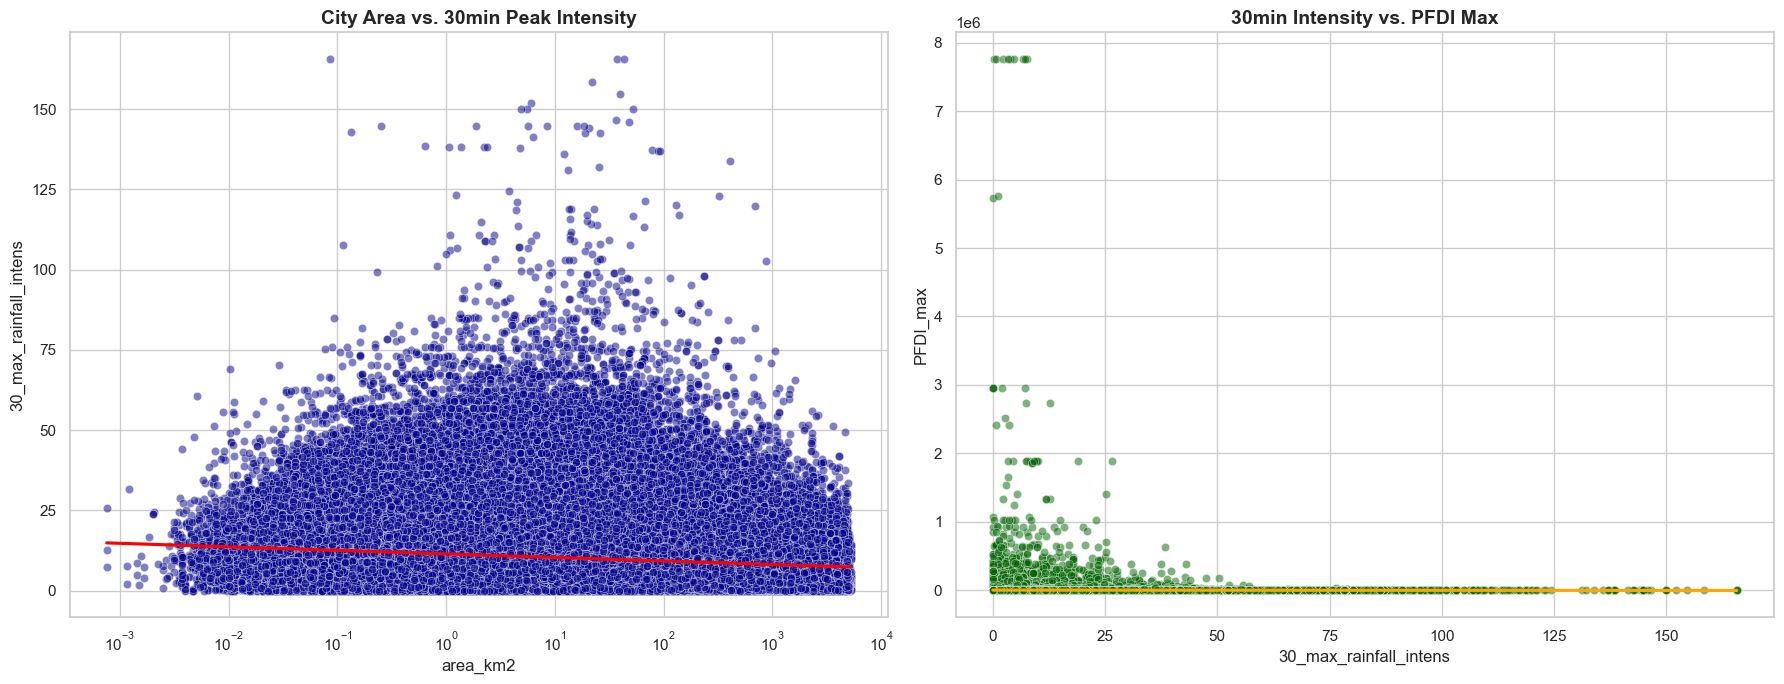

Correlation Matrix (Simple):
                          area_km2  30_max_rainfall_intens  \
area_km2                     1.000                  -0.126   
30_max_rainfall_intens      -0.126                   1.000   
1440_max_rainfall_intens    -0.031                   0.744   
PFDI_max                    -0.010                  -0.008   

                          1440_max_rainfall_intens  PFDI_max  
area_km2                                    -0.031    -0.010  
30_max_rainfall_intens                       0.744    -0.008  
1440_max_rainfall_intens                     1.000    -0.011  
PFDI_max                                    -0.011     1.000  


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set the style
sns.set_theme(style="whitegrid")

# --- 1. PREPARE DATA ---
# Focus on 30m (short) and 1440m (long/daily) for comparison
analysis_cols = ['area_km2', '30_max_rainfall_intens', '1440_max_rainfall_intens', 'PFDI_max']
plot_df = final_master_dataset[analysis_cols].dropna()

# --- 2. PLOT: AREA vs INTENSITY ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# Plot 30 min intensity vs Area
sns.scatterplot(data=plot_df, x='area_km2', y='30_max_rainfall_intens', 
                alpha=0.5, ax=ax1, color='darkblue')
ax1.set_xscale('log') # Areas vary by orders of magnitude
ax1.set_title('City Area vs. 30min Peak Intensity', fontsize=14, fontweight='bold')
ax1.set_xlabel('Area (km2) - Log Scale')
ax1.set_ylabel('Intensity (mm/hr)')

# Add a trend line (Regplot)
sns.regplot(data=plot_df, x='area_km2', y='30_max_rainfall_intens', 
            scatter=False, ax=ax1, color='red', logx=True)

# --- 3. PLOT: INTENSITY vs PFDI ---
# Does short-duration rain drive the flood index more than daily rain?
sns.scatterplot(data=plot_df, x='30_max_rainfall_intens', y='PFDI_max', 
                alpha=0.5, ax=ax2, color='darkgreen')
ax2.set_title('30min Intensity vs. PFDI Max', fontsize=14, fontweight='bold')
ax2.set_xlabel('30min Peak Intensity (mm/hr)')
ax2.set_ylabel('PFDI Max (Runoff Index)')

# Add a trend line
sns.regplot(data=plot_df, x='30_max_rainfall_intens', y='PFDI_max', 
            scatter=False, ax=ax2, color='orange')

plt.tight_layout()
plt.show()

# --- 4. CORRELATION TABLE ---
print("Correlation Matrix (Simple):")
print(plot_df.corr().round(3))

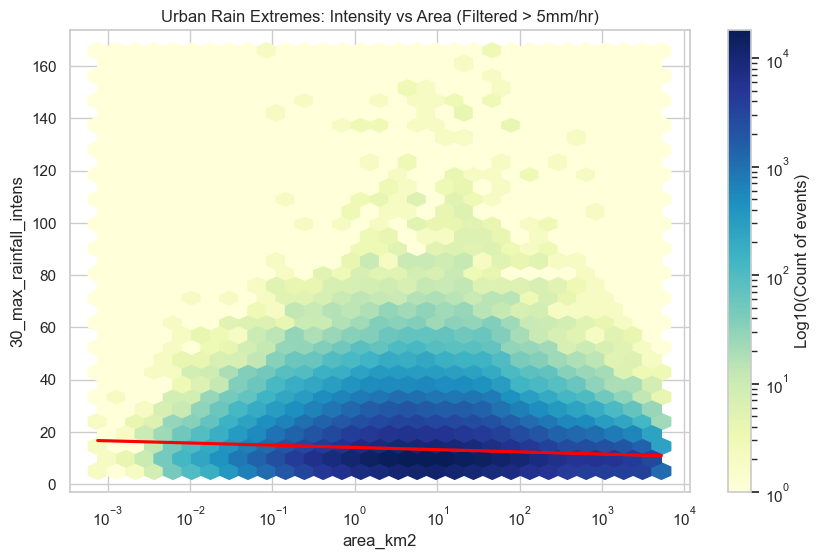

In [8]:
# --- ניתוח רק של אירועים משמעותיים ---
# נסנן רק אירועים שבהם ירד גשם מינימלי (למשל מעל 5 מ"מ/שעה)
extreme_events = plot_df[plot_df['30_max_rainfall_intens'] > 5]

plt.figure(figsize=(10, 6))
# שימוש ב-Hexbin במקום Scatter כדי לראות איפה הריכוז האמיתי (Density)
plt.hexbin(extreme_events['area_km2'], extreme_events['30_max_rainfall_intens'], 
           xscale='log', gridsize=30, cmap='YlGnBu', bins='log')

# הוספת קו רגרסיה רק לאירועים החזקים
sns.regplot(data=extreme_events, x='area_km2', y='30_max_rainfall_intens', 
            scatter=False, color='red', logx=True)

plt.title('Urban Rain Extremes: Intensity vs Area (Filtered > 5mm/hr)')
plt.colorbar(label='Log10(Count of events)')
plt.show()

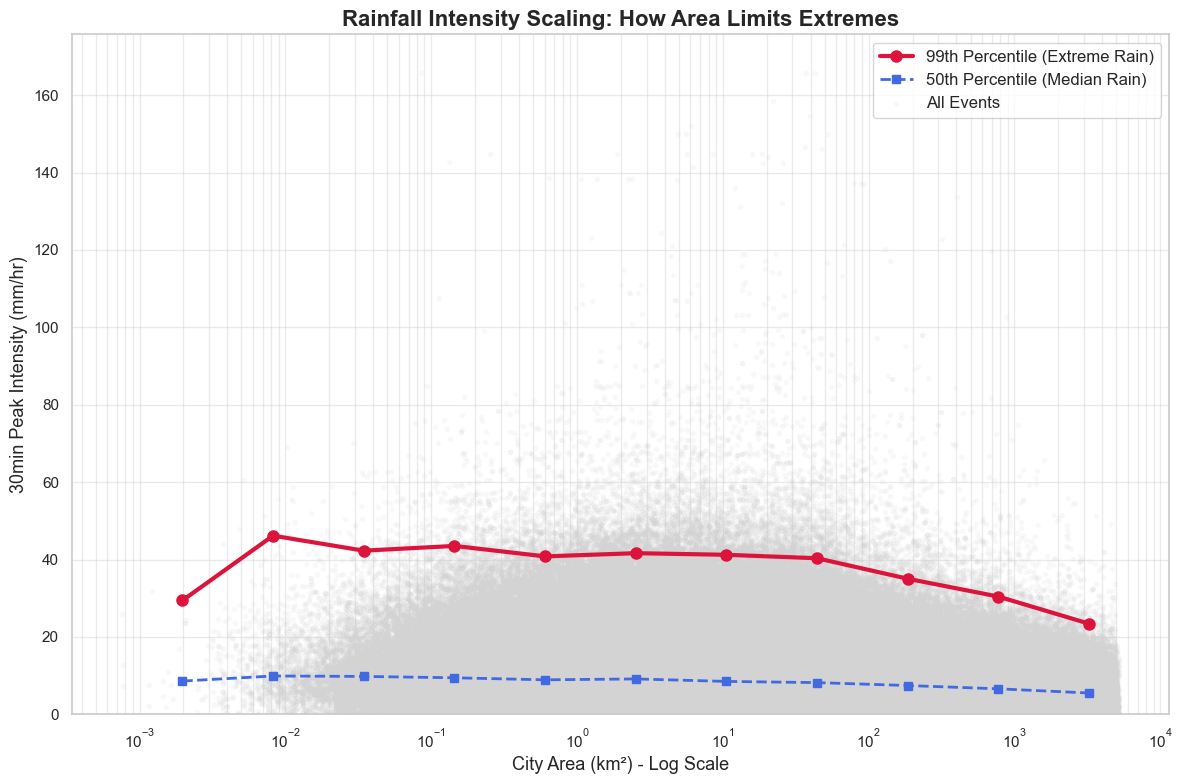


Summary Statistics by Area Bins:
                area_bin    p99   count
0     (0.00076, 0.00318]  29.43      33
1      (0.00318, 0.0133]  46.17    1062
2       (0.0133, 0.0557]  42.29    6465
3        (0.0557, 0.233]  43.52   29373
4         (0.233, 0.976]  40.81   87579
5         (0.976, 4.087]  41.64  161605
6        (4.087, 17.106]  41.22  192461
7       (17.106, 71.607]  40.33  160020
8      (71.607, 299.745]  35.03   95572
9    (299.745, 1254.724]  30.42   61209
10  (1254.724, 5252.243]  23.41   48974


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. DATA PREPARATION ---
# Filter for valid records and intensities > 0
df_plot = final_master_dataset[['area_km2', '30_max_rainfall_intens']].dropna()
df_plot = df_plot[df_plot['area_km2'] > 0]

# --- 2. LOG-BINNING FOR AREA ---
# Create 10 log-spaced bins to cover the full range of city sizes
min_area = df_plot['area_km2'].min()
max_area = df_plot['area_km2'].max()
bins = np.logspace(np.log10(min_area), np.log10(max_area), 12)

# Categorize each event into an area bin
df_plot['area_bin'] = pd.cut(df_plot['area_km2'], bins=bins)

# Calculate the 99th percentile and median for each bin
# We also count events to ensure statistical significance
bin_stats = df_plot.groupby('area_bin', observed=False)['30_max_rainfall_intens'].agg(
    p99=lambda x: np.percentile(x, 99) if len(x) > 10 else np.nan,
    p50=lambda x: np.percentile(x, 50) if len(x) > 10 else np.nan,
    count='count'
).reset_index()

# Use the midpoint of each bin for the X-axis plotting
bin_stats['bin_mid'] = bin_stats['area_bin'].apply(lambda x: x.mid).astype(float)

# --- 3. VISUALIZATION ---
plt.figure(figsize=(12, 8))
sns.set_theme(style="whitegrid")

# Plot all events in the background (light color to highlight the trend)
plt.scatter(df_plot['area_km2'], df_plot['30_max_rainfall_intens'], 
            alpha=0.1, color='lightgrey', s=8, label='All Events')

# Plot the 99th Percentile Line (The "Extreme Envelope")
plt.plot(bin_stats['bin_mid'], bin_stats['p99'], marker='o', color='crimson', 
         linewidth=3, markersize=8, label='99th Percentile (Extreme Rain)')

# Plot the Median for contrast
plt.plot(bin_stats['bin_mid'], bin_stats['p50'], marker='s', color='royalblue', 
         linewidth=2, linestyle='--', label='50th Percentile (Median Rain)')

# Formatting for Hydrological Analysis
plt.xscale('log')
plt.title('Rainfall Intensity Scaling: How Area Limits Extremes', fontsize=16, fontweight='bold')
plt.xlabel('City Area (km²) - Log Scale', fontsize=13)
plt.ylabel('30min Peak Intensity (mm/hr)', fontsize=13)
plt.grid(True, which="both", ls="-", alpha=0.4)
plt.legend(fontsize=12)

# Optional: Set Y-axis limit to focus on high intensities
plt.ylim(0, df_plot['30_max_rainfall_intens'].max() + 10)

plt.tight_layout()
plt.show()

# --- 4. PRINT SUMMARY TABLE ---
print("\nSummary Statistics by Area Bins:")
print(bin_stats[['area_bin', 'p99', 'count']].dropna().round(2))